In [13]:
import torch
import torchvision
from torchvision import transforms 
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from model import VAE

In [14]:
#from google.colab import drive
#drive.mount('/content/drive')

In [15]:
#!pip install kaggle

In [16]:
#!kaggle datasets download -d jessicali9530/celeba-dataset
#!unzip celeba-dataset.zip

In [17]:
#!mkdir celeba
#!mv celeba-dataset/img_align_celeba celeba/

In [18]:
def train(dataloader,epochs,model,optimizer,device,print_iterations_steps=10000):
    losses = []
    loss_fn =torch.nn.BCELoss(reduction='sum')
    model.train()
    best_loss = float('inf')
    for epoch in range(epochs):
        for i,(x,_) in enumerate(dataloader):
            x = x.to(device)
            mu,sigma,result = model(x)
            kl_divergence = -1/2 * torch.mean(1+torch.log(sigma.pow(2))-mu.pow(2)-sigma.pow(2))
            result_loss = loss_fn(result, x) 
            loss = kl_divergence + result_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            if (i % print_iterations_steps) == 0:
                print(f"Epoch: {epoch}, Loss: {torch.mean(torch.tensor(losses))}")
                if torch.mean(torch.tensor(losses)) < best_loss:
                    best_loss = torch.mean(torch.tensor(losses))
                    torch.save(model.state_dict(), f"/content/drive/MyDrive/vae_best.pth")
        
        torch.save(model.state_dict(), f"/content/drive/MyDrive/vae_{epoch}.pth")


In [19]:

IMG_SIZE = 128
BATCH_SIZE = 32

def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        #transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        #transforms.Lambda(lambda t: (t * 2) - 1) # Scale between [-1, 1] 
    ]
    data_transform = transforms.Compose(data_transforms)

    dataset = torchvision.datasets.ImageFolder(
        root="../data",
        transform=data_transform
    )
    # dataset = torchvision.datasets.MNIST(root=".", train=True, transform=data_transform, download=True)
    return dataset

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [20]:
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(8,64,IMG_SIZE,IMG_SIZE,ending_channels=3)

summary(model,(3,IMG_SIZE,IMG_SIZE))

model.load_state_dict(torch.load(f"models/vae_best.pth", weights_only=True))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.to(device)

Layer (type:depth-idx)                   Output Shape              Param #
├─Encoder: 1-1                           [-1, 32, 16, 16]          --
|    └─EncoderBlock: 2-1                 [-1, 8, 64, 64]           --
|    |    └─Conv2d: 3-1                  [-1, 8, 128, 128]         224
|    |    └─ReLU: 3-2                    [-1, 8, 128, 128]         --
|    |    └─Conv2d: 3-3                  [-1, 8, 128, 128]         584
|    |    └─ReLU: 3-4                    [-1, 8, 128, 128]         --
|    |    └─MaxPool2d: 3-5               [-1, 8, 64, 64]           --
|    └─EncoderBlock: 2-2                 [-1, 16, 32, 32]          --
|    |    └─Conv2d: 3-6                  [-1, 16, 64, 64]          1,168
|    |    └─ReLU: 3-7                    [-1, 16, 64, 64]          --
|    |    └─Conv2d: 3-8                  [-1, 16, 64, 64]          2,320
|    |    └─ReLU: 3-9                    [-1, 16, 64, 64]          --
|    |    └─MaxPool2d: 3-10              [-1, 16, 32, 32]          --
|    └─

VAE(
  (encoder): Encoder(
    (encoder_first): EncoderBlock(
      (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pooling): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU()
    )
    (encoder_second): EncoderBlock(
      (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pooling): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU()
    )
    (encoder_third): EncoderBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pooling): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU()
    )

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.to(device)


VAE(
  (encoder): Encoder(
    (encoder_first): EncoderBlock(
      (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pooling): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU()
    )
    (encoder_second): EncoderBlock(
      (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pooling): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU()
    )
    (encoder_third): EncoderBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pooling): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU()
    )

In [22]:
#train(dataloader, 10, model, optimizer, device, print_iterations_steps=100)
#torch.save(model.state_dict(), "../models/vae.pth")


In [23]:
def test():
    model.eval()
    image = next(iter(dataloader))[0][0].unsqueeze(0)
    mu,sigma,result = model(image.to(device))
    plt.imshow(result.cpu().detach().numpy()[0].transpose(1,2,0))
    plt.show()


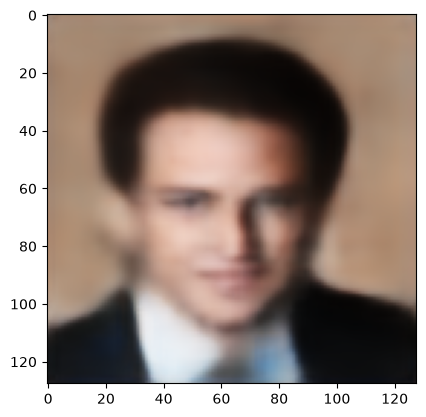

In [32]:
test()